# Step 1

Get parameters for desired qubit parameters

In [2]:
%load_ext autoreload
%autoreload 2

Setup Hugging face stuff

In [3]:
from squadds.core.utils import set_huggingface_api_key

set_huggingface_api_key()

API key already exists in .env file.


Access database

In [4]:
from datasets import get_dataset_config_names
from datasets import load_dataset

configs = get_dataset_config_names("SQuADDS/SQuADDS_DB")

components = []
component_names = []
data_types = []

for config in configs:
    try:
        components.append(config.split("-")[0])
        component_names.append(config.split("-")[1])
        data_types.append(config.split("-")[2])
    except:
        pass
    
print(components)
print(component_names)
print(data_types)

['qubit', 'cavity_claw', 'coupler', 'coupler', 'measured_device_database']
['TransmonCross', 'RouteMeander', 'NCap', 'CapNInterdigitalTee']
['cap_matrix', 'eigenmode', 'cap_matrix', 'cap_matrix']


In [5]:
from squadds import SQuADDS_DB

db = SQuADDS_DB()

In [6]:
db.get_configs()

['qubit-TransmonCross-cap_matrix',
 'cavity_claw-RouteMeander-eigenmode',
 'coupler-NCap-cap_matrix',
 'coupler-CapNInterdigitalTee-cap_matrix']


In [7]:
db.select_system(["qubit","cavity_claw"])

In [8]:
db.select_qubit("TransmonCross")
db.select_cavity_claw("RouteMeander")
db.select_resonator_type("quarter")

In [9]:
db.show_selections()

Selected qubit:  TransmonCross
Selected cavity:  RouteMeander
Selected coupler to feedline:  CLT
Selected resonator type:  quarter
Selected system:  ['qubit', 'cavity_claw']


In [10]:
merged_df = db.create_system_df()

In [11]:
merged_df

,index_qc,renderer_options_qubit,setup_qubit,simulator_qubit,PI_qubit,date_created_qubit,group_qubit,institution_qubit,uploader_qubit,claw_to_claw,...,PI_cavity_claw,date_created_cavity_claw,group_cavity_claw,institution_cavity_claw,misc,uploader_cavity_claw,renderer_options_cavity_claw,setup_cavity_claw,simulator_cavity_claw,design_options
0,0,"{'Cj': 0, 'Lj': '10nH', '_Rj': 0, 'design_name...","{'auto_increase_solution_order': True, 'enable...",Ansys HFSS,"Eli Levenson-Falk, PhD",2023-09-20-142547,LFL,USC,Andre Kuo,94.97421,...,"Eli Levenson-Falk, PhD",2023-12-09-204334,LFL,USC,None,Andre Kuo,None,"{'basis_order': 1, 'max_delta_f': 0.05, 'max_p...",Ansys HFSS,{'cavity_claw_options': {'coupler_type': 'CLT'...
1,0,"{'Cj': 0, 'Lj': '10nH', '_Rj': 0, 'design_name...","{'auto_increase_solution_order': True, 'enable...",Ansys HFSS,"Eli Levenson-Falk, PhD",2023-09-20-142547,LFL,USC,Andre Kuo,94.97421,...,"Eli Levenson-Falk, PhD",2023-12-06-224829,LFL,USC,None,Andre Kuo,None,"{'basis_order': 1, 'max_delta_f': 0.05, 'max_p...",Ansys HFSS,{'cavity_claw_options': {'coupler_type': 'CLT'...
2,0,"{'Cj': 0, 'Lj': '10nH', '_Rj': 0, 'design_name...","{'auto_increase_solution_order': True, 'enable...",Ansys HFSS,"Eli Levenson-Falk, PhD",2023-09-20-142547,LFL,USC,Andre Kuo,94.97421,...,"Eli Levenson-Falk, PhD",2023-12-04-124953,LFL,USC,None,Andre Kuo,None,"{'basis_order': 1, 'max_delta_f': 0.05, 'max_p...",Ansys HFSS,{'cavity_claw_options': {'coupler_type': 'CLT'...
3,0,"{'Cj': 0, 'Lj': '10nH', '_Rj': 0, 'design_name...","{'auto_increase_solution_order': True, 'enable...",Ansys HFSS,"Eli Levenson-Falk, PhD",2023-09-20-142547,LFL,USC,Andre Kuo,94.97421,...,"Eli Levenson-Falk, PhD",2023-12-08-173545,LFL,USC,None,Andre Kuo,None,"{'basis_order': 1, 'max_delta_f': 0.05, 'max_p...",Ansys HFSS,{'cavity_claw_options': {'coupler_type': 'CLT'...
4,0,"{'Cj': 0, 'Lj': '10nH', '_Rj': 0, 'design_name...","{'auto_increase_solution_order': True, 'enable...",Ansys HFSS,"Eli Levenson-Falk, PhD",2023-09-20-142547,LFL,USC,Andre Kuo,94.97421,...,"Eli Levenson-Falk, PhD",2023-11-30-214122,LFL,USC,None,Andre Kuo,None,"{'basis_order': 1, 'max_delta_f': 0.05, 'max_p...",Ansys HFSS,{'cavity_claw_options': {'coupler_type': 'CLT'...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22191,1642,"{'Cj': 0, 'Lj': '10nH', '_Rj': 0, 'design_name...","{'auto_increase_solution_order': True, 'enable...",Ansys HFSS,"Eli Levenson-Falk, PhD",2023-09-20-142547,LFL,USC,Andre Kuo,183.80802,...,"Eli Levenson-Falk, PhD",2024-01-25-214631,LFL,USC,,Andre Kuo,None,"{'basis_order': 1, 'max_delta_f': 0.05, 'max_p...",Ansys HFSS,{'cavity_claw_options': {'coupler_type': 'CLT'...
22192,1642,"{'Cj': 0, 'Lj': '10nH', '_Rj': 0, 'design_name...","{'auto_increase_solution_order': True, 'enable...",Ansys HFSS,"Eli Levenson-Falk, PhD",2023-09-20-142547,LFL,USC,Andre Kuo,183.80802,...,"Eli Levenson-Falk, PhD",2024-07-12-141659,LFL,USC,None,Ethan Zheng,None,"{'basis_order': 1, 'max_delta_f': 0.05, 'max_p...",Ansys HFSS,{'cavity_claw_options': {'coupler_type': 'CLT'...
22193,1642,"{'Cj': 0, 'Lj': '10nH', '_Rj': 0, 'design_name...","{'auto_increase_solution_order': True, 'enable...",Ansys HFSS,"Eli Levenson-Falk, PhD",2023-09-20-142547,LFL,USC,Andre Kuo,183.80802,...,"Eli Levenson-Falk, PhD",2024-07-24-230000,LFL,USC,None,Ethan Zheng,None,"{'basis_order': 1, 'max_delta_f': 0.05, 'max_p...",Ansys HFSS,{'cavity_claw_options': {'coupler_type': 'CLT'...
22194,1642,"{'Cj': 0, 'Lj': '10nH', '_Rj': 0, 'design_name...","{'auto_increase_solution_order': True, 'enable...",Ansys HFSS,"Eli Levenson-Falk, PhD",2023-09-20-142547,LFL,USC,Andre Kuo,183.80802,...,"Eli Levenson-Falk, PhD",2024-07-24-230000,LFL,USC,None,Ethan Zheng,None,"{'basis_order': 1, 'max_delta_f': 0.05, 'max_p...",Ansys HFSS,{'cavity_claw_options': {'coupler_type': 'CLT'...


In [12]:
from squadds import Analyzer

In [13]:
analyzer = Analyzer(db)

In [14]:
db.selected_system

['qubit', 'cavity_claw']

In [15]:
analyzer.selected_system

['qubit', 'cavity_claw']

In [16]:
target_params = {
                "qubit_frequency_GHz": 4,
                "cavity_frequency_GHz": 7.4,
                "kappa_kHz": 120,
                "resonator_type":"quarter",
                "anharmonicity_MHz": -200,
                "g_MHz": 70}

In [ ]:
results = analyzer.find_closest(target_params=target_params,
                                       num_top=1,
                                       metric="Euclidean",
                                       display=True)


Time taken to add the coupled H params: 3.2627944946289062 seconds


'fF'

In [23]:
results.values[0]

array([812,
       {'Cj': 0, 'Lj': '10nH', '_Rj': 0, 'design_name': None, 'max_mesh_length_jj': '7um', 'max_mesh_length_port': '7um', 'plot_ansys_fields_options': {'AdjacentSidePlot': 'False', 'FullModelPlot': 'False', 'IntrinsicVar': "Phase='0deg'", 'PlotFolder': 'E Field', 'PlotGeomInfo_0': '1', 'PlotGeomInfo_1': 'Surface', 'PlotGeomInfo_2': 'FacesList', 'PlotGeomInfo_3': '1', 'QuantityName': 'Mag_E', 'StreamlinePlot': 'False', 'UserSpecifyFolder': '0', 'UserSpecifyName': '0', 'name': 'NAME:Mag_E1'}, 'project_name': None, 'project_path': None, 'wb_offset': '0um', 'wb_size': 5, 'wb_threshold': '400um', 'x_buffer_width_mm': 0.2, 'y_buffer_width_mm': 0.2},
       {'auto_increase_solution_order': True, 'enabled': True, 'freq_ghz': 5.0, 'max_passes': 30, 'min_converged_passes': 1, 'min_passes': 2, 'name': 'sweep_setup', 'percent_error': 0.1, 'percent_refinement': 30, 'reuse_selected_design': False, 'reuse_setup': False, 'run': {'box_plus_buffer': True, 'components': array(['Q'], dtype=obj

In [25]:
%matplotlib inline

In [26]:
from squadds.interpolations.physics import ScalingInterpolator

In [27]:
interpolator = ScalingInterpolator(analyzer, target_params)

design_df = interpolator.get_design()

Kappa scaling: 0.9637788277521582
g scaling: 1.0033220328956947
alpha scaling: 1.0111571303804734
resonator scaling: 0.9005645809716217


In [28]:
design_df.values[0]

array(['CLT',
       {'aedt_hfss_capacitance': 0, 'aedt_hfss_inductance': 1.331327875025721e-08, 'aedt_q3d_capacitance': 0, 'aedt_q3d_inductance': 1.331327875025721e-08, 'chip': 'main', 'connection_pads': {'readout': {'claw_cpw_length': '0um', 'claw_cpw_width': '10um', 'claw_gap': '5.1um', 'claw_length': '152.17743414454702um', 'claw_width': '15um', 'connector_location': '90', 'connector_type': '0', 'ground_spacing': '4.1um', 'Lj': '13.31327875025721nH'}}, 'cross_gap': '30um', 'cross_length': '212.3429973798994um', 'cross_width': '30um', 'gds_cell_name': 'my_other_junction', 'hfss_capacitance': 0, 'hfss_inductance': 1.331327875025721e-08, 'hfss_mesh_kw_jj': 7e-06, 'hfss_resistance': 0, 'layer': '1', 'orientation': '-90', 'pos_x': '-1500um', 'pos_y': '1200um', 'q3d_capacitance': 0, 'q3d_inductance': 1.331327875025721e-08, 'q3d_mesh_kw_jj': 7e-06, 'q3d_resistance': 0},
       {'claw_opts': {'connection_pads': {'readout': {'claw_cpw_length': '0um', 'claw_cpw_width': '10um', 'claw_gap': '5

In [ ]:
from squadds.components.coupled_systems import QubitCavity
import qiskit_metal as metal
from qiskit_metal import Dict, MetalGUI, designs, draw
from qiskit_metal.toolbox_metal import math_and_overrides

design = metal.designs.design_planar.DesignPlanar()
gui = metal.MetalGUI(design)
design.overwrite_enabled = True

qc_ncap = QubitCavity(design, "qubit_cavity", options=design_df.iloc[0]["design_options"])
gui.rebuild()
gui.autoscale()
gui.screenshot("qubit_quarter_wave_cavity")

There might be "kinks" in the CPW, which is a known issue in `qiskit-metal`.
To resolve this, try adjusting the `start_straight` or `end_straight` parameters.
For more details and resolution tips, check out this guide:
https://qiskit-community.github.io/qiskit-metal/tut/2-From-components-to-chip/2.12-Simple-Meander.html
There might be "kinks" in the CPW, which is a known issue in `qiskit-metal`.
To resolve this, try adjusting the `start_straight` or `end_straight` parameters.
For more details and resolution tips, check out this guide:
https://qiskit-community.github.io/qiskit-metal/tut/2-From-components-to-chip/2.12-Simple-Meander.html


There might be "kinks" in the CPW, which is a known issue in `qiskit-metal`.
To resolve this, try adjusting the `start_straight` or `end_straight` parameters.
For more details and resolution tips, check out this guide:
https://qiskit-community.github.io/qiskit-metal/tut/2-From-components-to-chip/2.12-Simple-Meander.html


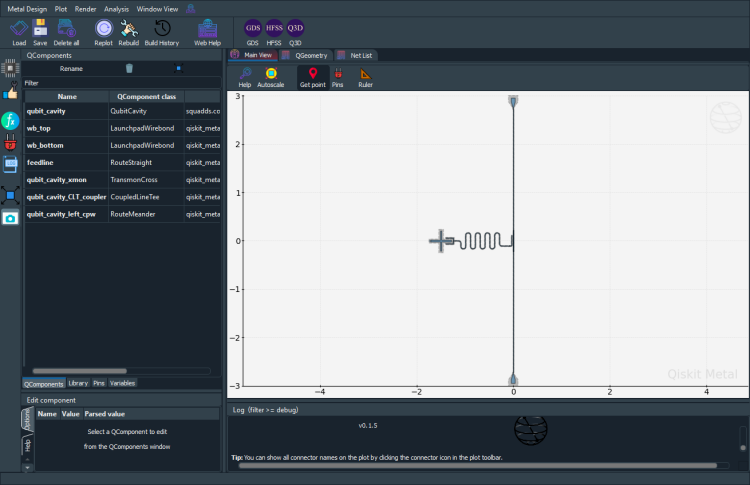

In [ ]:
# qc_ncap.show(gui, include_wirebond_pads=True)

In [25]:
qc_ncap.to_gds("qubit_cavity", include_wirebond_pads=False)

04:20PM 51s WARNING [_import_junction_gds_file]: Not able to find file:"../resources/Fake_Junctions.GDS".  Not used to replace junction. Checked directory:"c:\Users\91566\Desktop\rz\Qubit_Design\qubit_design\resources".
